In [2]:
import time
import random
import numpy as np
import matplotlib.pyplot as plt
import sys

sys.setrecursionlimit(3000)

print("Crunchyroll-style Analytics Engine: Ready.")

Crunchyroll-style Analytics Engine: Ready.


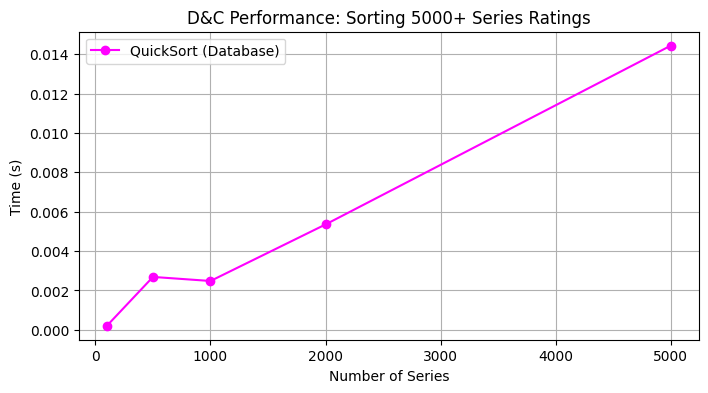

In [3]:
def sort_manhwa_ratings(arr):
    if len(arr) <= 1:
        return arr
    pivot = arr[len(arr) // 2]
    left = [x for x in arr if x > pivot]
    middle = [x for x in arr if x == pivot]
    right = [x for x in arr if x < pivot]
    return sort_manhwa_ratings(left) + middle + sort_manhwa_ratings(right)

def benchmark_sorting():
    sizes = [100, 500, 1000, 2000, 5000]
    times = []
    for s in sizes:
        data = [random.uniform(1.0, 10.0) for _ in range(s)]
        start = time.time()
        sort_manhwa_ratings(data)
        times.append(time.time() - start)

    plt.figure(figsize=(8, 4))
    plt.plot(sizes, times, marker='o', color='magenta', label='QuickSort (Database)')
    plt.title("D&C Performance: Sorting 5000+ Series Ratings")
    plt.xlabel("Number of Series")
    plt.ylabel("Time (s)")
    plt.legend()
    plt.grid(True)
    plt.show()

benchmark_sorting()

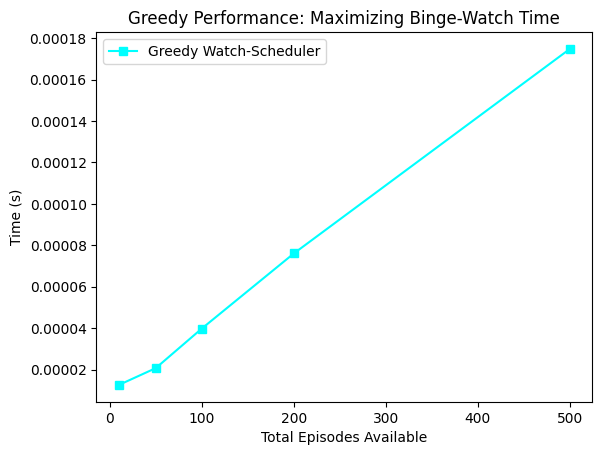

In [4]:
def binge_schedule(episodes):
    episodes.sort(key=lambda x: x[1])
    watchlist = [episodes[0]]
    last_end = episodes[0][1]

    for i in range(1, len(episodes)):
        if episodes[i][0] >= last_end:
            watchlist.append(episodes[i])
            last_end = episodes[i][1]
    return watchlist

def plot_greedy_binge():
    sizes = [10, 50, 100, 200, 500]
    times = []
    for s in sizes:
        data = []
        for _ in range(s):
            start = random.randint(1, 20)
            data.append((start, start + random.randint(1, 3)))
        start_t = time.time()
        binge_schedule(data)
        times.append(time.time() - start_t)

    plt.plot(sizes, times, marker='s', color='cyan', label='Greedy Watch-Scheduler')
    plt.title("Greedy Performance: Maximizing Binge-Watch Time")
    plt.xlabel("Total Episodes Available")
    plt.ylabel("Time (s)")
    plt.legend()
    plt.show()

plot_greedy_binge()

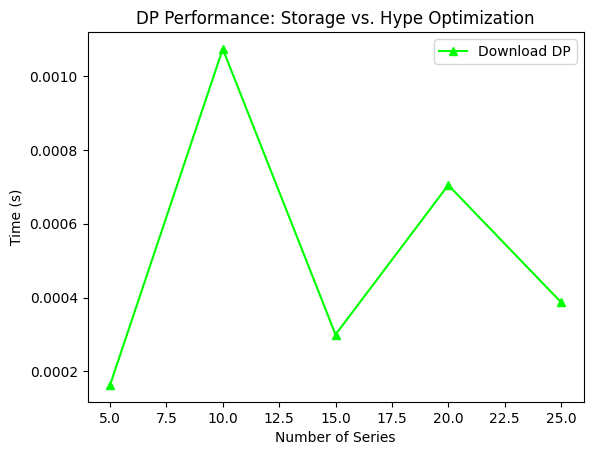

In [5]:
def download_optimizer(storage, sizes, hype, n):
    dp = [[0 for _ in range(storage + 1)] for _ in range(n + 1)]
    for i in range(1, n + 1):
        for w in range(1, storage + 1):
            if sizes[i-1] <= w:
                dp[i][w] = max(hype[i-1] + dp[i-1][w-sizes[i-1]], dp[i-1][w])
            else:
                dp[i][w] = dp[i-1][w]
    return dp[n][storage]

def plot_dp_downloads():
    num_items = [5, 10, 15, 20, 25]
    times = []
    for n in num_items:
        s = [random.randint(1, 10) for _ in range(n)]
        h = [random.randint(50, 100) for _ in range(n)]
        start = time.time()
        download_optimizer(50, s, h, n)
        times.append(time.time() - start)

    plt.plot(num_items, times, marker='^', color='lime', label='Download DP')
    plt.title("DP Performance: Storage vs. Hype Optimization")
    plt.xlabel("Number of Series")
    plt.ylabel("Time (s)")
    plt.legend()
    plt.show()

plot_dp_downloads()

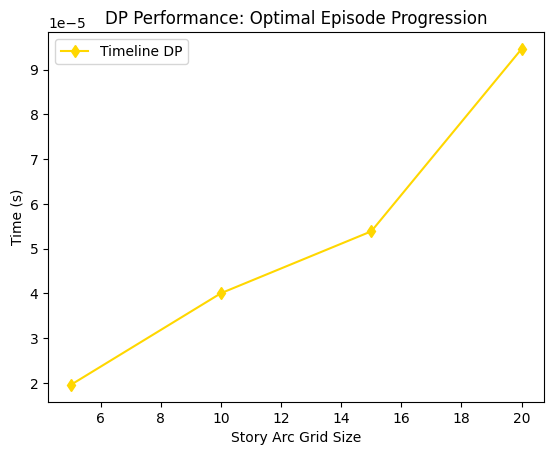

In [6]:
def story_arc_path(grid):
    m, n = len(grid), len(grid[0])
    for i in range(1, m): grid[i][0] += grid[i-1][0]
    for j in range(1, n): grid[0][j] += grid[0][j-1]
    for i in range(1, m):
        for j in range(1, n):
            grid[i][j] += min(grid[i-1][j], grid[i][j-1])
    return grid[m-1][n-1]

def plot_story_path():
    dimensions = [5, 10, 15, 20]
    times = []
    for d in dimensions:
        grid = [[random.randint(1, 5) for _ in range(d)] for _ in range(d)]
        start = time.time()
        story_arc_path(grid)
        times.append(time.time() - start)

    plt.plot(dimensions, times, marker='d', color='gold', label='Timeline DP')
    plt.title("DP Performance: Optimal Episode Progression")
    plt.xlabel("Story Arc Grid Size")
    plt.ylabel("Time (s)")
    plt.legend()
    plt.show()

plot_story_path()